> 📝 **Planning note (author use -- remove before publishing)**
>
> **Intended contents:** load two real moorings (AT200 + AT800), combine onto a common time base, compare visually and via scatter plot, Pearson correlation.

**To do:** fix the SyntaxError from prose sitting in a code cell; remove the `xr.corr??` debugging leftover; fix "PLot" typo; fill in bullet placeholders; tie in interpolation-awareness from notebook 6 (what `combine_datasets` is doing under the hood when aligning two different sampling intervals).

# Comparing and correlating data from different instruments

We often want to compare or correlate records from different instruments -- for example, two moorings at different locations, or sensors at different depths. Before we can do that, we usually need to combine the datasets onto a common time base first.

So: combining is a means to an end here, not the point itself -- the goal is the comparison/correlation that follows.

In [1]:
#import xarray as xr
from kval.data import moored
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib widget

## Combining the two records

- 

In [2]:
ds1 = moored.load_moored('../../data/moored_CTD_test_data/intermediate_data/AT200_21_22_SBE37_15252_113m_from_raw.nc')
ds2 = moored.load_moored('../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_from_raw.nc')

In [6]:
ds_combined = moored.combine_datasets(ds1, ds2, interval = '1D', instr_names = ['AT200', 'AT800'])

In [7]:
ds_combined

<xarray.Dataset> Size: 43kB
Dimensions:                                 (INSTR: 2, TIME: 333)
Coordinates: (12/20)
  * INSTR                                   (INSTR) <U5 40B 'AT200' 'AT800'
  * TIME                                    (TIME) datetime64[ns] 3kB 2021-11...
    CNDC_sensor_calibration_date            (INSTR) <U10 80B '13-Feb-20' '201...
    CNDC_sensor_serial_number               (INSTR) object 16B '15252' None
    PRES_assumed_atmospheric_pressure_dbar  (INSTR) object 16B None 10.13
    PRES_sensor_calibration_date            (INSTR) <U10 80B '11-Feb-20' '201...
    ...                                      ...
    history                                 (INSTR) <U162 1kB '2021-11-07 - 2...
    instrument_model                        (INSTR) <U22 176B 'Sea-Bird SBE37...
    instrument_serial_number                (INSTR) <U21 168B '15252' '60595'
    sampling_details                        (INSTR) object 16B None 'One aver...
    source_file                             (INSTR) <U115 920B 'SBE37SM-RS232...
    time_coverage_resolution                (INSTR) <U20 160B 'P0000-00-00T00...
Data variables:
    CNDC                                    (INSTR, TIME) float64 5kB -0.0075...
    DEPTH                                   (INSTR, TIME) float64 5kB nan ......
    PRES                                    (INSTR, TIME) float64 5kB -0.3493...
    PSAL                                    (INSTR, TIME) float64 5kB nan ......
    SPCNDC                                  (INSTR, TIME) float64 5kB nan ......
    SVEL                                    (INSTR, TIME) float64 5kB nan ......
    TEMP                                    (INSTR, TIME) float64 5kB 3.314 ....
    LATITUDE                                (INSTR) float64 16B 81.0 81.0
    LONGITUDE                               (INSTR) float64 16B 30.0 30.0

## Comparing and correlating the two records

- 
- 
- 

In [10]:
xr.corr(ds1_daily.TEMP, ds2_daily.TEMP)

<xarray.DataArray 'TEMP' ()> Size: 8B
array(0.59183349)

## PLot together

In [11]:
moored.plot(ds_combined)

## Scatter plot


In [12]:
TEMP_AT200 = ds_combined.TEMP.sel(INSTR = 'AT200')
TEMP_AT800 = ds_combined.TEMP.sel(INSTR = 'AT800')

Text(0, 0.5, 'TEMP, AT800 [°C]')

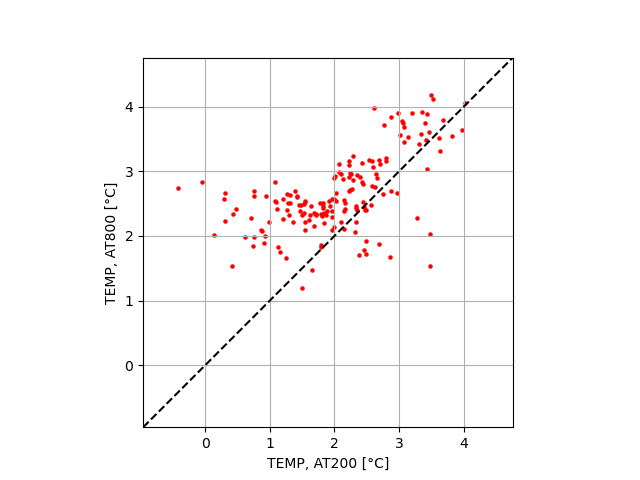

In [16]:

fig, ax = plt.subplots()
ax.scatter(TEMP_AT200, TEMP_AT800, s = 5, color = 'r')
ax.set_aspect('equal')
ax.grid()
ax.axline((-0.7, -0.7), (4.5, 4.5), color = 'k', ls = '--')
ax.set_xlabel('TEMP, AT200 [°C]')
ax.set_ylabel('TEMP, AT800 [°C]')

## Correlation

 Pearson correlation coefficient of the two time series 

In [15]:
xr.corr(TEMP_AT200, TEMP_AT800)

<xarray.DataArray 'TEMP' ()> Size: 8B
array(0.5952854)

In [ ]:
ds1_daily = moored.time_average(ds1, '1D')
ds2_daily = moored.time_average(ds2, '1D')
xr.corr(TEMP_AT200, TEMP_AT800)